# Part 3 — J.T. Reilly: MOA validation

This notebook validates the drug-to-mechanism-of-action (MOA) encoding used by the logistic-regression data, asks whether local fitness peaks (refuges) are enriched for particular MOA classes, and compares basin-size dominance against the paper-style drug logistic-regression coefficients.

In [2]:
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Locate the repository root from wherever the notebook kernel starts.
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / "data" / "Logistic Regression Data and Code").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError("Could not locate the CSBIO185_cell_mates project root")

LOGREG_DIR = PROJECT_ROOT / "data" / "Logistic Regression Data and Code"
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

BASINS_PATH = OUTPUT_DIR / "basins.pkl"
if not BASINS_PATH.exists():
    raise FileNotFoundError(
        f"Expected Part 2 basin pickle at {BASINS_PATH}. "
        "Run Notebook 2 first, then rerun this notebook."
    )

with open(BASINS_PATH, "rb") as fh:
    basins = pickle.load(fh)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"LOGREG_DIR   = {LOGREG_DIR}")
print(f"Loaded {len(basins):,} basins from {BASINS_PATH}")
print(f"Largest basin: {next(iter(basins))} ({len(next(iter(basins.values()))):,} nodes)")

PROJECT_ROOT = C:\Users\lukes\Downloads\CSBIO185_cell_mates
LOGREG_DIR   = C:\Users\lukes\Downloads\CSBIO185_cell_mates\data\Logistic Regression Data and Code
Loaded 664 basins from C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\basins.pkl
Largest basin: DOX3+TMP3 (3,186 nodes)


## Validate Drug → MOA Mapping

The `SINGLES_LOGREG*.csv` files encode drug presence, while the parallel `SINGLES_MOA*.csv` files encode the MOA classes for the same rows. We cross-check the two tables row by row using the drug-to-MOA assignment implied by the published data.

In [3]:
DRUGS = ["AMP", "CPR", "DOX", "ERY", "FOX", "FUS", "STR", "TMP"]
MOA_COLS = ["C_Wall", "F_Acid", "DNA_gyr", "30s", "50s"]

# Mapping that exactly reproduces the authors' SINGLES_MOA*.csv encoding.
# Note that this is the paper/data encoding used for validation and downstream comparison.
DRUG_TO_MOA = {
    "AMP": "C_Wall",
    "CPR": "DNA_gyr",
    "DOX": "50s",
    "ERY": "50s",
    "FOX": "C_Wall",
    "FUS": "30s",
    "STR": "30s",
    "TMP": "F_Acid",
}


def expected_moa_from_drug_row(row):
    """Return the MOA indicator vector implied by a LOGREG drug-presence row."""
    present_moas = {DRUG_TO_MOA[drug] for drug in DRUGS if int(row[drug]) == 1}
    return {moa: int(moa in present_moas) for moa in MOA_COLS}


validation_frames = []
for subset_size in [3, 4, 5]:
    drug_df = pd.read_csv(LOGREG_DIR / f"SINGLES_LOGREG{subset_size}.csv")
    moa_df = pd.read_csv(LOGREG_DIR / f"SINGLES_MOA{subset_size}.csv")

    if len(drug_df) != len(moa_df):
        raise ValueError(f"Row count mismatch for subset size {subset_size}")

    expected = pd.DataFrame([expected_moa_from_drug_row(row) for _, row in drug_df.iterrows()])
    observed = moa_df[MOA_COLS].astype(int).reset_index(drop=True)
    drug_part = drug_df[["suppression", *DRUGS]].astype(int).reset_index(drop=True)
    moa_part = moa_df[["SUPR", *MOA_COLS]].astype(int).reset_index(drop=True)

    row_check = pd.concat(
        [drug_part.add_prefix("drug_"), moa_part.add_prefix("moa_"), expected.add_prefix("expected_")],
        axis=1,
    )
    row_check.insert(0, "subset_size", subset_size)
    row_check.insert(1, "source_row", np.arange(1, len(row_check) + 1))
    row_check["suppression_matches"] = row_check["drug_suppression"] == row_check["moa_SUPR"]
    row_check["moa_matches"] = (observed.to_numpy() == expected.to_numpy()).all(axis=1)
    validation_frames.append(row_check)

moa_validation = pd.concat(validation_frames, ignore_index=True)
moa_mismatches = moa_validation.loc[
    ~(moa_validation["suppression_matches"] & moa_validation["moa_matches"])
].copy()

mismatch_path = OUTPUT_DIR / "part3_moa_mapping_mismatches.csv"
moa_mismatches.to_csv(mismatch_path, index=False)

print(f"Rows checked       : {len(moa_validation):,}")
print(f"Mapping mismatches : {(~moa_validation['moa_matches']).sum():,}")
print(f"SUPR mismatches    : {(~moa_validation['suppression_matches']).sum():,}")
print(f"Mismatch file      : {mismatch_path}")

if moa_mismatches.empty:
    print("All SINGLES_MOA rows match the expected drug-to-MOA mapping.")
else:
    display(moa_mismatches.head(20))

Rows checked       : 20,784
Mapping mismatches : 0
SUPR mismatches    : 0
Mismatch file      : C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\part3_moa_mapping_mismatches.csv
All SINGLES_MOA rows match the expected drug-to-MOA mapping.


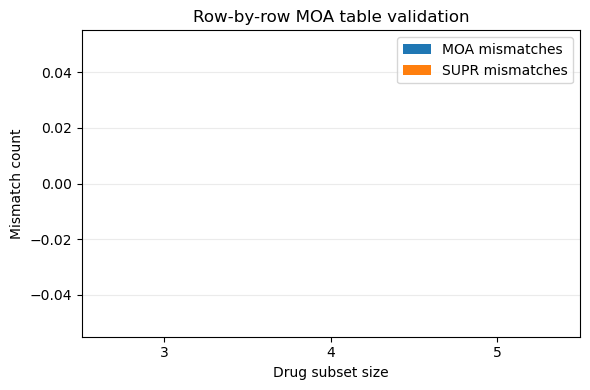

,rows,moa_mismatches,supr_mismatches
subset_size,,,
3,1512,0,0
4,5670,0,0
5,13602,0,0


In [4]:
# A compact diagnostic plot makes the validation result visible even when there are no mismatches.
validation_summary = moa_validation.groupby("subset_size").agg(
    rows=("source_row", "count"),
    moa_mismatches=("moa_matches", lambda s: int((~s).sum())),
    supr_mismatches=("suppression_matches", lambda s: int((~s).sum())),
)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(validation_summary.index))
width = 0.36
ax.bar(x - width / 2, validation_summary["moa_mismatches"], width, label="MOA mismatches")
ax.bar(x + width / 2, validation_summary["supr_mismatches"], width, label="SUPR mismatches")
ax.set_xticks(x)
ax.set_xticklabels(validation_summary.index)
ax.set_xlabel("Drug subset size")
ax.set_ylabel("Mismatch count")
ax.set_title("Row-by-row MOA table validation")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(validation_summary)

## MOA Enrichment In Refuges

A refuge is a local fitness peak from Part 2. For each subset size and MOA class, we compare MOA presence among peaks against the non-peak baseline. I also include a basin-size weighted peak rate, because larger basins attract more evolutionary paths.

In [5]:
NODE_TOKEN_RE = re.compile(r"([A-Z]{3})(\d+)")


def drugs_from_node_id(node_id):
    """Parse a graph node id such as 'DOX3+TMP3' into its drug names."""
    if node_id == "EMPTY":
        return []
    return [match.group(1) for match in NODE_TOKEN_RE.finditer(node_id)]


peak_to_basin_size = {peak: len(members) for peak, members in basins.items()}
node_to_peak = {
    node_id: peak
    for peak, members in basins.items()
    for node_id in members
}

node_records = []
for node_id, peak_id in node_to_peak.items():
    drugs = drugs_from_node_id(node_id)
    present_moas = {DRUG_TO_MOA[drug] for drug in drugs}
    record = {
        "node_id": node_id,
        "peak_id": peak_id,
        "subset_size": len(drugs),
        "is_peak": node_id in peak_to_basin_size,
        "terminal_basin_size": peak_to_basin_size[peak_id],
        "peak_basin_size": peak_to_basin_size.get(node_id, np.nan),
        "drug_combo": "+".join(drugs) if drugs else "EMPTY",
    }
    record.update({moa: int(moa in present_moas) for moa in MOA_COLS})
    node_records.append(record)

node_table = pd.DataFrame(node_records)
peak_table = node_table[node_table["is_peak"]].copy()
nonpeak_table = node_table[~node_table["is_peak"]].copy()

rows = []
for subset_size in sorted(node_table["subset_size"].unique()):
    if subset_size == 0:
        continue
    peaks_k = peak_table[peak_table["subset_size"] == subset_size]
    nonpeaks_k = nonpeak_table[nonpeak_table["subset_size"] == subset_size]
    for moa in MOA_COLS:
        peak_rate = peaks_k[moa].mean() if len(peaks_k) else np.nan
        nonpeak_rate = nonpeaks_k[moa].mean() if len(nonpeaks_k) else np.nan
        if len(peaks_k):
            weighted_peak_rate = np.average(peaks_k[moa], weights=peaks_k["peak_basin_size"])
        else:
            weighted_peak_rate = np.nan
        rows.append({
            "subset_size": subset_size,
            "moa": moa,
            "n_peaks": len(peaks_k),
            "n_nonpeaks": len(nonpeaks_k),
            "peak_presence_rate": peak_rate,
            "basin_weighted_peak_presence_rate": weighted_peak_rate,
            "nonpeak_presence_rate": nonpeak_rate,
            "enrichment_delta": peak_rate - nonpeak_rate,
            "basin_weighted_enrichment_delta": weighted_peak_rate - nonpeak_rate,
            "enrichment_ratio": peak_rate / nonpeak_rate if nonpeak_rate and not np.isnan(nonpeak_rate) else np.nan,
        })

enrichment_table = pd.DataFrame(rows)

node_table_path = OUTPUT_DIR / "part3_peak_node_table.csv"
enrichment_path = OUTPUT_DIR / "part3_moa_enrichment.csv"
node_table.to_csv(node_table_path, index=False)
enrichment_table.to_csv(enrichment_path, index=False)

print(f"Nodes summarized      : {len(node_table):,}")
print(f"Peaks/refuges         : {len(peak_table):,}")
print(f"Peak node table       : {node_table_path}")
print(f"MOA enrichment table  : {enrichment_path}")

display(enrichment_table.round(3))

with open("enrichment_table.pkl",  "wb") as f:
    pickle.dump(enrichment_table, f)

Nodes summarized      : 21,067
Peaks/refuges         : 664
Peak node table       : C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\part3_peak_node_table.csv
MOA enrichment table  : C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\part3_moa_enrichment.csv


,subset_size,moa,n_peaks,n_nonpeaks,peak_presence_rate,basin_weighted_peak_presence_rate,nonpeak_presence_rate,enrichment_delta,basin_weighted_enrichment_delta,enrichment_ratio
0,1,C_Wall,0,24,NaN,NaN,0.250,NaN,NaN,NaN
1,1,F_Acid,0,24,NaN,NaN,0.125,NaN,NaN,NaN
2,1,DNA_gyr,0,24,NaN,NaN,0.125,NaN,NaN,NaN
3,1,30s,0,24,NaN,NaN,0.250,NaN,NaN,NaN
4,1,50s,0,24,NaN,NaN,0.250,NaN,NaN,NaN
5,2,C_Wall,6,246,0.000,0.000,0.476,-0.476,-0.476,0.000
6,2,F_Acid,6,246,0.833,0.987,0.236,0.598,0.751,3.534
7,2,DNA_gyr,6,246,0.167,0.013,0.252,-0.085,-0.239,0.661
8,2,30s,6,246,0.167,0.013,0.472,-0.305,-0.458,0.353
9,2,50s,6,246,0.833,0.987,0.455,0.378,0.532,1.830


### MOA Enrichment Visualization

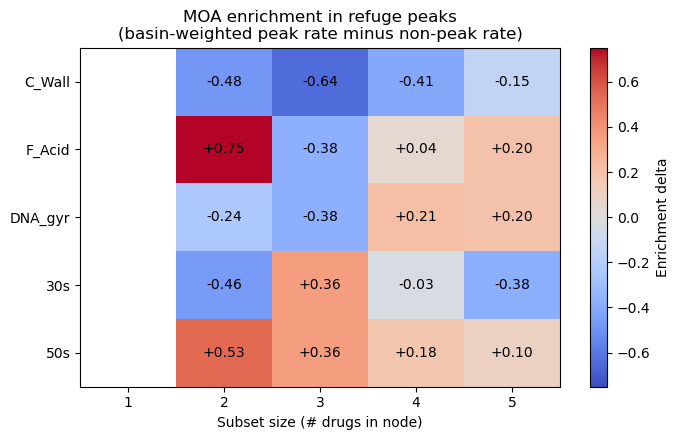

,node_id,subset_size,peak_basin_size,drug_combo,C_Wall,F_Acid,DNA_gyr,30s,50s
0,DOX3+TMP3,2,3186.0,DOX+TMP,0,1,0,0,1
3186,DOX1+TMP3,2,1231.0,DOX+TMP,0,1,0,0,1
4417,DOX2+TMP2,2,1142.0,DOX+TMP,0,1,0,0,1
5559,DOX3+ERY3+FUS3,3,854.0,DOX+ERY+FUS,0,0,0,1,1
6413,DOX2+TMP3,2,850.0,DOX+TMP,0,1,0,0,1
7263,DOX3+TMP1,2,848.0,DOX+TMP,0,1,0,0,1
8111,CPR1+DOX3+FUS3+TMP3,4,630.0,CPR+DOX+FUS+TMP,0,1,1,1,1
8741,CPR3+DOX2+ERY3+FUS3,4,346.0,CPR+DOX+ERY+FUS,0,0,1,1,1
9087,DOX1+ERY3+FOX3+FUS3,4,316.0,DOX+ERY+FOX+FUS,1,0,0,1,1
9403,CPR2+DOX2+ERY3+FUS3+TMP3,5,288.0,CPR+DOX+ERY+FUS+TMP,0,1,1,1,1


In [6]:
heatmap_data = enrichment_table.pivot(
    index="moa",
    columns="subset_size",
    values="basin_weighted_enrichment_delta",
).reindex(MOA_COLS)

fig, ax = plt.subplots(figsize=(7, 4.5))
max_abs = np.nanmax(np.abs(heatmap_data.to_numpy()))
im = ax.imshow(heatmap_data, cmap="coolwarm", vmin=-max_abs, vmax=max_abs, aspect="auto")
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("Subset size (# drugs in node)")
ax.set_title("MOA enrichment in refuge peaks\n(basin-weighted peak rate minus non-peak rate)")

for i, moa in enumerate(heatmap_data.index):
    for j, subset_size in enumerate(heatmap_data.columns):
        value = heatmap_data.loc[moa, subset_size]
        if not np.isnan(value):
            ax.text(j, i, f"{value:+.2f}", ha="center", va="center", color="black")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Enrichment delta")
plt.tight_layout()
plt.show()

top_refuges = peak_table.sort_values("peak_basin_size", ascending=False).head(15)
display(top_refuges[["node_id", "subset_size", "peak_basin_size", "drug_combo", *MOA_COLS]])

## Compare Against Paper's Logistic Regression

The paper's R script fits no-intercept logistic models of suppression on drug indicators. The code below reproduces that setup with a small NumPy IRLS solver, then compares average drug coefficients against basin-size dominance: the fraction of all graph nodes whose terminal refuge contains each drug.

Drug comparison table : C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\part3_drug_basin_logreg_comparison.csv
Logreg coefficients   : C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\part3_logreg_coefficients_by_subset_size.csv


,drug,moa,n_refuge_peaks_containing_drug,basin_nodes_ending_at_drug_peak,basin_dominance_fraction,mean_refuge_basin_size,mean_logreg_coef,mean_odds_ratio,basin_dominance_rank,logreg_coef_rank
0,DOX,50s,498,19679,0.934,39.516,0.152,1.166,1,5
1,TMP,F_Acid,457,17026,0.808,37.256,0.700,2.023,2,1
2,ERY,50s,550,11859,0.563,21.562,0.222,1.290,3,3
3,CPR,DNA_gyr,474,10306,0.489,21.743,0.266,1.325,4,2
4,FUS,30s,352,8181,0.388,23.241,-0.720,0.495,5,7
5,FOX,C_Wall,362,5184,0.246,14.320,0.168,1.205,6,4
6,AMP,C_Wall,373,5172,0.246,13.866,-0.218,0.819,7,6
7,STR,30s,205,1421,0.067,6.932,-1.103,0.399,8,8


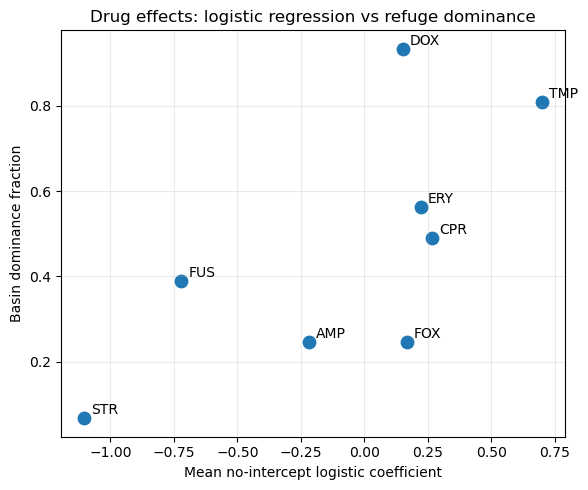

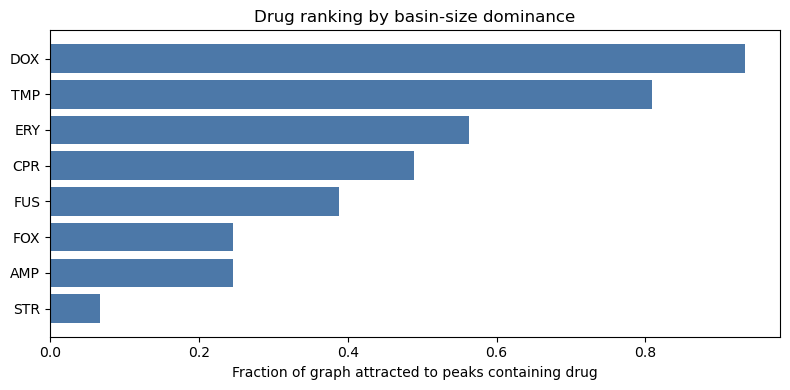

In [7]:
def fit_logistic_no_intercept(X, y, max_iter=100, tol=1e-8, ridge=1e-6):
    """Fit y ~ X + 0 with iteratively reweighted least squares.

    The tiny ridge term only stabilizes near-separated columns; it is small enough
    to preserve the coefficient ordering used for comparison here.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    beta = np.zeros(X.shape[1], dtype=float)

    for _ in range(max_iter):
        eta = X @ beta
        mu = 1 / (1 + np.exp(-np.clip(eta, -35, 35)))
        weights = np.clip(mu * (1 - mu), 1e-9, None)
        z = eta + (y - mu) / weights
        Xw = X * weights[:, None]
        hessian = X.T @ Xw + ridge * np.eye(X.shape[1])
        rhs = X.T @ (weights * z)
        beta_next = np.linalg.solve(hessian, rhs)
        if np.max(np.abs(beta_next - beta)) < tol:
            beta = beta_next
            break
        beta = beta_next
    return beta


coef_frames = []
for subset_size in [3, 4, 5]:
    df = pd.read_csv(LOGREG_DIR / f"SINGLES_LOGREG{subset_size}.csv")
    beta = fit_logistic_no_intercept(df[DRUGS].to_numpy(), df["suppression"].to_numpy())
    coef_frames.append(pd.DataFrame({
        "subset_size": subset_size,
        "drug": DRUGS,
        "logreg_coef": beta,
        "odds_ratio": np.exp(beta),
    }))

logreg_coefficients = pd.concat(coef_frames, ignore_index=True)
logreg_summary = logreg_coefficients.groupby("drug", as_index=False).agg(
    mean_logreg_coef=("logreg_coef", "mean"),
    mean_odds_ratio=("odds_ratio", "mean"),
)

rank_rows = []
total_nodes = sum(len(members) for members in basins.values())
for drug in DRUGS:
    peaks_with_drug = [peak for peak in basins if drug in drugs_from_node_id(peak)]
    basin_nodes_ending_at_drug_peak = sum(len(basins[peak]) for peak in peaks_with_drug)
    rank_rows.append({
        "drug": drug,
        "moa": DRUG_TO_MOA[drug],
        "n_refuge_peaks_containing_drug": len(peaks_with_drug),
        "basin_nodes_ending_at_drug_peak": basin_nodes_ending_at_drug_peak,
        "basin_dominance_fraction": basin_nodes_ending_at_drug_peak / total_nodes,
        "mean_refuge_basin_size": basin_nodes_ending_at_drug_peak / len(peaks_with_drug) if peaks_with_drug else np.nan,
    })

basin_drug_rankings = pd.DataFrame(rank_rows).sort_values(
    "basin_dominance_fraction", ascending=False
)
comparison_table = basin_drug_rankings.merge(logreg_summary, on="drug", how="left")
comparison_table["basin_dominance_rank"] = comparison_table["basin_dominance_fraction"].rank(
    ascending=False, method="min"
).astype(int)
comparison_table["logreg_coef_rank"] = comparison_table["mean_logreg_coef"].rank(
    ascending=False, method="min"
).astype(int)
comparison_table = comparison_table.sort_values("basin_dominance_rank")

comparison_path = OUTPUT_DIR / "part3_drug_basin_logreg_comparison.csv"
coefficients_path = OUTPUT_DIR / "part3_logreg_coefficients_by_subset_size.csv"
comparison_table.to_csv(comparison_path, index=False)
logreg_coefficients.to_csv(coefficients_path, index=False)

print(f"Drug comparison table : {comparison_path}")
print(f"Logreg coefficients   : {coefficients_path}")
display(comparison_table.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(comparison_table["mean_logreg_coef"], comparison_table["basin_dominance_fraction"], s=80)
for _, row in comparison_table.iterrows():
    ax.annotate(row["drug"], (row["mean_logreg_coef"], row["basin_dominance_fraction"]), xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("Mean no-intercept logistic coefficient")
ax.set_ylabel("Basin dominance fraction")
ax.set_title("Drug effects: logistic regression vs refuge dominance")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = comparison_table.sort_values("basin_dominance_fraction", ascending=True)
ax.barh(plot_df["drug"], plot_df["basin_dominance_fraction"], color="#4C78A8")
ax.set_xlabel("Fraction of graph attracted to peaks containing drug")
ax.set_title("Drug ranking by basin-size dominance")
plt.tight_layout()
plt.show()

## Hand Off To Notebook 4

Notebook 4 can load the CSVs written below to polish the MOA enrichment heatmap and integrate the basin/logistic-regression comparison into the final visualization narrative.

In [8]:
handoff_files = {
    "MOA row-validation mismatches": mismatch_path,
    "Node/peak MOA table": node_table_path,
    "MOA enrichment summary": enrichment_path,
    "Drug basin/logreg comparison": comparison_path,
    "Subset-specific logreg coefficients": coefficients_path,
}

for label, path in handoff_files.items():
    print(f"{label}: {path}")

MOA row-validation mismatches: C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\part3_moa_mapping_mismatches.csv
Node/peak MOA table: C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\part3_peak_node_table.csv
MOA enrichment summary: C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\part3_moa_enrichment.csv
Drug basin/logreg comparison: C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\part3_drug_basin_logreg_comparison.csv
Subset-specific logreg coefficients: C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\part3_logreg_coefficients_by_subset_size.csv
